In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import seaborn as sns


In [2]:
df_alojamientos =pd.read_csv("../data/clean/df_proj_alojamientos.csv")

# Revisión General del Dataset Alojamientos

In [3]:
print("\n=== 1) DIMENSIONES ===")
print("Filas, columnas:", df_alojamientos.shape)


=== 1) DIMENSIONES ===
Filas, columnas: (4880, 12)


In [4]:
print("\n=== 2) INFO / TIPOS ===")
print(df_alojamientos.info())


=== 2) INFO / TIPOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4880 entries, 0 to 4879
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   mes                          4880 non-null   int64  
 1   ccaa                         4880 non-null   object 
 2   provincia                    4880 non-null   object 
 3   categoria_alojamiento        4880 non-null   object 
 4   periodo_antelacion           4880 non-null   object 
 5   precio_checkin_entre_semana  4880 non-null   float64
 6   precio_checkin_fin_semana    4880 non-null   float64
 7   valoraciones                 4880 non-null   float64
 8   fuente                       4880 non-null   object 
 9   tiene_valoraciones           4880 non-null   bool   
 10  latitud                      4795 non-null   float64
 11  longitud                     4795 non-null   float64
dtypes: bool(1), float64(5), int64(1), object(5)
memory 

In [5]:
print("\n=== 3) VALORES NULOS (conteo y %) ===")
null_count = df_alojamientos.isna().sum()
null_pct = (null_count / len(df_alojamientos) * 100).round(2)
nulls = pd.DataFrame({"nulos": null_count, "%": null_pct}).sort_values("nulos", ascending=False)
print(nulls)


=== 3) VALORES NULOS (conteo y %) ===
                             nulos     %
longitud                        85  1.74
latitud                         85  1.74
mes                              0  0.00
ccaa                             0  0.00
categoria_alojamiento            0  0.00
provincia                        0  0.00
periodo_antelacion               0  0.00
precio_checkin_entre_semana      0  0.00
valoraciones                     0  0.00
precio_checkin_fin_semana        0  0.00
tiene_valoraciones               0  0.00
fuente                           0  0.00


In [6]:
print("\n=== 4) FILAS COMPLETAMENTE VACÍAS ===")
empty_rows = df_alojamientos.isna().all(axis=1).sum()
print("Filas totalmente vacías:", empty_rows)


=== 4) FILAS COMPLETAMENTE VACÍAS ===
Filas totalmente vacías: 0


In [7]:
print("\n=== 5) DUPLICADOS ===")
dup_rows = df_alojamientos.duplicated().sum()
print("Filas duplicadas exactas:", dup_rows)


=== 5) DUPLICADOS ===
Filas duplicadas exactas: 0


In [8]:
# Duplicados ignorando columnas "variables" (por ejemplo valoraciones puede variar)
# Ajusta esta lista si querés probar otros subconjuntos
subset_cols = ["mes", "ccaa", "provincia", "categoria_alojamiento", "periodo_antelacion",
               "precio_checkin_entre_semana", "precio_checkin_fin_semana"]
dup_subset = df_alojamientos.duplicated(subset=subset_cols).sum()
print(f"Duplicados por subset {subset_cols}:", dup_subset)

if dup_rows > 0:
    print("\nEjemplos de duplicados exactos:")
    print(df_alojamientos[df_alojamientos.duplicated()].head(10))

print("\n=== 6) VALORES ÚNICOS (cardinalidad) ===")
unique_counts = df_alojamientos.nunique().sort_values(ascending=False)
print(unique_counts)
print("\n=== 7) CALIDAD DE TEXTO (espacios / mayúsculas raras) ===")
text_cols = df_alojamientos.select_dtypes(include="object").columns
for c in text_cols:
    has_leading = df_alojamientos[c].astype(str).str.startswith(" ").any()
    has_trailing = df_alojamientos[c].astype(str).str.endswith(" ").any()
    if has_leading or has_trailing:
        print(f"Columna '{c}': tiene espacios al inicio/fin -> leading={has_leading}, trailing={has_trailing}")

print("\n=== 8) RESUMEN NUMÉRICO ===")
num_cols = df_alojamientos.select_dtypes(include=["int64", "float64"]).columns
print(df_alojamientos[num_cols].describe().T.round(2))

print("\n=== 9) CHEQUEOS RÁPIDOS DE CONSISTENCIA ===")

Duplicados por subset ['mes', 'ccaa', 'provincia', 'categoria_alojamiento', 'periodo_antelacion', 'precio_checkin_entre_semana', 'precio_checkin_fin_semana']: 0

=== 6) VALORES ÚNICOS (cardinalidad) ===
precio_checkin_fin_semana      2299
precio_checkin_entre_semana    2176
valoraciones                   1867
provincia                        52
latitud                          50
longitud                         50
ccaa                             19
mes                              12
categoria_alojamiento             8
periodo_antelacion                2
fuente                            2
tiene_valoraciones                1
dtype: int64

=== 7) CALIDAD DE TEXTO (espacios / mayúsculas raras) ===

=== 8) RESUMEN NUMÉRICO ===
                              count    mean     std    min    25%     50%  \
mes                          4880.0    6.50    3.45   1.00   4.00    7.00   
precio_checkin_entre_semana  4880.0  153.01  104.51  22.63  88.48  131.53   
precio_checkin_fin_semana    4880

In [9]:
# 9.1 tiene_valoraciones vs valoraciones
consistencia_val = (df_alojamientos["valoraciones"].notna() == df_alojamientos["tiene_valoraciones"]).mean()
print(f"Consistencia valoraciones vs tiene_valoraciones: {consistencia_val*100:.2f}% (100% es ideal)")


Consistencia valoraciones vs tiene_valoraciones: 100.00% (100% es ideal)


In [10]:
# 9.2 precios negativos o cero (si esto no debería pasar)
for col in ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]:
    neg = (df_alojamientos[col] < 0).sum()
    zero = (df_alojamientos[col] == 0).sum()
    print(f"{col}: negativos={neg}, ceros={zero}")

precio_checkin_entre_semana: negativos=0, ceros=0
precio_checkin_fin_semana: negativos=0, ceros=0


In [11]:
# 9.3 rango válido de mes (esperado 1-12)
invalid_months = df_alojamientos[~df_alojamientos["mes"].between(1, 12)]
print("Meses fuera de 1-12:", len(invalid_months))
if len(invalid_months) > 0:
    print(invalid_months[["mes"]].drop_duplicates().head())

Meses fuera de 1-12: 0


# Analisis EDA de Alojamientos

In [12]:
price_cols = ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]

## Valores extremos (outliers) en precios

In [13]:
# =========================
# EDA 1: OUTLIERS EN PRECIOS
# =========================
df_out = df_alojamientos.copy()
price_cols = ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]

def iqr_summary(s: pd.Series):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return q1, q3, iqr, low, high, int(mask.sum()), float(mask.mean() * 100)

# 1) Tabla de outliers por IQR
rows = []
for c in price_cols:
    q1, q3, iqr, low, high, n_out, pct_out = iqr_summary(df_out[c])
    rows.append([c, round(q1,2), round(q3,2), round(iqr,2), round(low,2), round(high,2), n_out, round(pct_out,2)])

out_iqr = pd.DataFrame(rows, columns=[
    "variable", "Q1", "Q3", "IQR", "lim_inf_IQR", "lim_sup_IQR", "n_outliers", "%_outliers"
])

print("=== OUTLIERS POR IQR (1.5*IQR) ===")
out_iqr


=== OUTLIERS POR IQR (1.5*IQR) ===


,variable,Q1,Q3,IQR,lim_inf_IQR,lim_sup_IQR,n_outliers,%_outliers
0,precio_checkin_entre_semana,88.48,190.04,101.56,-63.85,342.37,145,2.97
1,precio_checkin_fin_semana,98.67,201.73,103.06,-55.91,356.32,155,3.18


Proporción de outliers baja y controlada
Entre semana: Outliers: 145 observaciones (2.97%)
Fin de semana: Outliers: 155 observaciones (3.18%)
IQR entre semana: ≈ 101.6 €
IQR fin de semana: ≈ 103.1 €
Alta heterogeneidad natural de precios
Diferencias reales por: categoría de alojamiento/territorio/estacionalida
Limite Inferios
Weekday: –63.85 €
Weekend: –55.91 €
El método IQR es simétrico/Los precios reales están acotados por 0/No hay precios negativos reales
Limite Superior:
Weekday: ≈ 342 €
Weekend: ≈ 356 €
destinos premium/alta temporada/categorías altas (hoteles 4–5★, zonas muy turísticas)

El análisis de valores extremos mediante el criterio IQR (1.5×IQR) muestra que los outliers representan menos del 4% de las observaciones tanto para precios entre semana como de fin de semana. Esta proporción reducida indica que el dataset presenta una distribución estable y no está dominado por valores atípicos.
Los valores extremos se concentran mayoritariamente en la cola superior de la distribución, lo que resulta coherente con la existencia de destinos y categorías de alojamiento de alto precio, especialmente en contextos de alta demanda turística. Por este motivo, se decidió conservar dichos valores en el análisis, al considerarse representativos de la realidad del mercado y relevantes para la simulación de escenarios de gasto.
En consecuencia, los outliers no se interpretan como errores de medición, sino como expresiones legítimas de la heterogeneidad del mercado turístico español.

In [14]:
# 2) Percentiles clave
percentiles = [0.01, 0.05, 0.10, 0.90, 0.95, 0.99]
pct_tbl = df_out[price_cols].quantile(percentiles).T
pct_tbl.columns = [f"p{int(p*100):02d}" for p in percentiles]
pct_tbl = pct_tbl.round(2)

print("=== PERCENTILES CLAVE (1,5,10,90,95,99) ===")
pct_tbl


=== PERCENTILES CLAVE (1,5,10,90,95,99) ===


,p01,p05,p10,p90,p95,p99
precio_checkin_entre_semana,33.98,50.23,68.50,254.83,302.43,501.24
precio_checkin_fin_semana,33.98,50.23,74.25,268.22,322.95,514.81


Entre semana/p10 ≈ 68.5 €-p90 ≈ 254.8 €
Fin de semana/p10 ≈ 74.3 €-p90 ≈ 268.2 €
El 80% central del mercado se mueve aproximadamente entre: 70–255 € (weekday) y 75–270 € (weekend)
Existe un segmento de bajo costo bien definido:/alojamientos económicos/destinos menos demandados/temporadas bajas
p01 ≈ 34 €
p05 ≈ 50 €
Hay un segmento premium reducido pero relevante, con precios muy elevados:
p95: weekday ≈ 302 €-weekend ≈ 323 €
p99: weekday ≈ 501 €-weekend ≈ 515 €

El análisis de percentiles muestra que la mayor parte de los precios de alojamiento se concentra en un rango claramente definido, situándose el 80% de las observaciones entre aproximadamente 70 y 270 euros por noche, dependiendo del tipo de día. Este rango representa el comportamiento típico del mercado y resulta especialmente útil para la estimación de presupuestos y la generación de recomendaciones estándar.
Asimismo, se identifica un segmento económico de bajo costo (percentiles 1 y 5) y una cola superior pronunciada correspondiente a alojamientos premium, especialmente visible a partir del percentil 95. Estos valores elevados no se interpretan como anomalías, sino como expresiones legítimas de destinos y categorías de alto precio.
El análisis confirma además un diferencial sistemático entre precios de fin de semana y entre semana a lo largo de toda la distribución, lo que respalda la inclusión explícita de esta distinción en el modelo. En conjunto, estos resultados justifican el uso de medidas robustas como la mediana y los percentiles en lugar de la media para la modelización de precio

In [15]:
# 3) Top 10 altos y bajos (para ver “quiénes son”)
cols_show = ["mes","ccaa","provincia","categoria_alojamiento","periodo_antelacion",
             "precio_checkin_entre_semana","precio_checkin_fin_semana","valoraciones","tiene_valoraciones"]

for c in price_cols:
    print(f"\n=== TOP 10 MÁS ALTOS: {c} ===")
    display(df_out.sort_values(c, ascending=False)[cols_show].head(10))

    print(f"\n=== TOP 10 MÁS BAJOS: {c} ===")
    display(df_out.sort_values(c, ascending=True)[cols_show].head(10))



=== TOP 10 MÁS ALTOS: precio_checkin_entre_semana ===


,mes,ccaa,provincia,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,valoraciones,tiene_valoraciones
4432,11,cantabria,cantabria,apartamento,1 mes,1753.37,1753.366667,4.68,True
3559,7,illes balears,illes balears,habitacion compartida,2-3 meses,1637.86,1637.855000,3.22,True
2021,1,illes balears,illes balears,habitacion compartida,1 mes,1396.51,1396.510000,3.06,True
2533,3,illes balears,illes balears,habitacion compartida,1 mes,1382.51,1382.510000,2.74,True
2789,4,illes balears,illes balears,habitacion compartida,1 mes,1359.69,1359.690000,2.53,True
2277,2,illes balears,illes balears,habitacion compartida,1 mes,1349.79,1349.786667,2.96,True
3045,5,illes balears,illes balears,habitacion compartida,1 mes,1308.93,1308.930000,3.27,True
3302,6,illes balears,illes balears,habitacion compartida,2-3 meses,1198.31,1198.313333,3.43,True
4330,10,illes balears,illes balears,habitacion compartida,1 mes,1165.80,1165.805000,3.12,True
4844,12,illes balears,illes balears,habitacion compartida,2-3 meses,1084.99,1084.990000,2.44,True



=== TOP 10 MÁS BAJOS: precio_checkin_entre_semana ===


,mes,ccaa,provincia,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,valoraciones,tiene_valoraciones
3435,7,castilla y leon,avila,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3438,7,castilla y leon,palencia,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3437,7,castilla y leon,leon,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3436,7,castilla y leon,burgos,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3439,7,castilla y leon,salamanca,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3442,7,castilla y leon,valladolid,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3441,7,castilla y leon,soria,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3440,7,castilla y leon,segovia,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3443,7,castilla y leon,zamora,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3592,7,region de murcia,murcia,habitacion compartida,2-3 meses,23.85,23.853333,4.64,True



=== TOP 10 MÁS ALTOS: precio_checkin_fin_semana ===


,mes,ccaa,provincia,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,valoraciones,tiene_valoraciones
4432,11,cantabria,cantabria,apartamento,1 mes,1753.37,1753.366667,4.68,True
3559,7,illes balears,illes balears,habitacion compartida,2-3 meses,1637.86,1637.855000,3.22,True
2021,1,illes balears,illes balears,habitacion compartida,1 mes,1396.51,1396.510000,3.06,True
2533,3,illes balears,illes balears,habitacion compartida,1 mes,1382.51,1382.510000,2.74,True
2789,4,illes balears,illes balears,habitacion compartida,1 mes,1359.69,1359.690000,2.53,True
2277,2,illes balears,illes balears,habitacion compartida,1 mes,1349.79,1349.786667,2.96,True
3045,5,illes balears,illes balears,habitacion compartida,1 mes,1308.93,1308.930000,3.27,True
3302,6,illes balears,illes balears,habitacion compartida,2-3 meses,1198.31,1198.313333,3.43,True
4330,10,illes balears,illes balears,habitacion compartida,1 mes,1165.80,1165.805000,3.12,True
4844,12,illes balears,illes balears,habitacion compartida,2-3 meses,1084.99,1084.990000,2.44,True



=== TOP 10 MÁS BAJOS: precio_checkin_fin_semana ===


,mes,ccaa,provincia,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,valoraciones,tiene_valoraciones
3436,7,castilla y leon,burgos,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3443,7,castilla y leon,zamora,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3442,7,castilla y leon,valladolid,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3441,7,castilla y leon,soria,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3440,7,castilla y leon,segovia,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3439,7,castilla y leon,salamanca,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3438,7,castilla y leon,palencia,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3437,7,castilla y leon,leon,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3435,7,castilla y leon,avila,habitacion compartida,2-3 meses,22.63,22.633333,4.10,True
3592,7,region de murcia,murcia,habitacion compartida,2-3 meses,23.85,23.853333,4.64,True


Precios más altos
Alta concentración en: Illes Balears y Cantabria
Categorías: apartamento y habitación compartida (pero en destinos muy tensionados)
Precios weekday ≈ weekend, lo que sugiere: mercado con demanda constante/destinos saturados
Precios más bajos Provincias de Castilla y León
Categoría casi exclusiva: habitación compartida, Precios idénticos repetidos (≈ 22.63 €): indican precios agregados o mínimos de referencia no variabilidad → baja presión de demanda

La variabilidad de precios está mucho más asociada al territorio y la presión turística que a la categoría de alojamiento en sí.

In [16]:
# 4) Flags de outliers (no borrarlos, solo marcar)
def mark_iqr_outliers(s: pd.Series) -> pd.Series:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return (s < low) | (s > high)

df_out["out_weekday"] = mark_iqr_outliers(df_out["precio_checkin_entre_semana"])
df_out["out_weekend"] = mark_iqr_outliers(df_out["precio_checkin_fin_semana"])
df_out["out_any"] = df_out[["out_weekday", "out_weekend"]].any(axis=1)

print("=== % GLOBAL CON OUTLIERS ===")
print("Weekday:", round(df_out["out_weekday"].mean()*100,2), "%")
print("Weekend:", round(df_out["out_weekend"].mean()*100,2), "%")
print("Any:", round(df_out["out_any"].mean()*100,2), "%")

print("\n=== % OUTLIERS POR CATEGORIA ===")
(df_out.groupby("categoria_alojamiento")["out_any"].mean().mul(100).round(2).sort_values(ascending=False))


=== % GLOBAL CON OUTLIERS ===
Weekday: 2.97 %
Weekend: 3.18 %
Any: 3.59 %

=== % OUTLIERS POR CATEGORIA ===


categoria_alojamiento
hotel 5 estrellas        15.17
alternativo               4.33
casa entera               3.85
apartamento               2.45
habitacion compartida     2.01
habitacion privada        0.96
hotel 3 estrellas         0.00
hotel 4 estrellas         0.00
Name: out_any, dtype: float64

Weekend ≥ Weekday El premium existe, pero no es uniforme. Varía por categoría, territorio estacionalidad. En destinos muy demandados, el premium desaparece → precios planos

El efecto “fin de semana” no es universal y depende del contexto turístico; en destinos saturados el precio ya internaliza la demanda máxima.

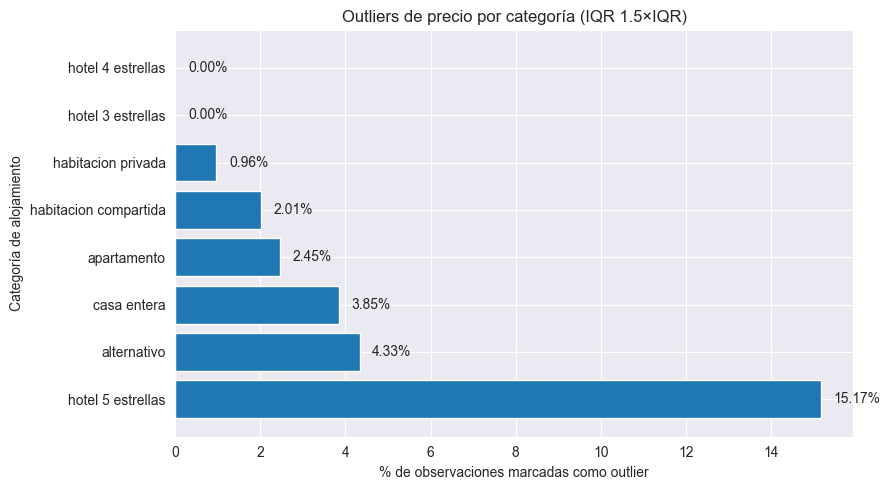

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\outliers_por_categoria_iqr.png


In [17]:
# 5) Gráfico % outliers por categoría
out_by_cat = (
    df_out.groupby("categoria_alojamiento")["out_any"]
     .mean()
     .mul(100)
     .round(2)
     .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))
bars = plt.barh(out_by_cat.index, out_by_cat.values)
plt.title("Outliers de precio por categoría (IQR 1.5×IQR)")
plt.xlabel("% de observaciones marcadas como outlier")
plt.ylabel("Categoría de alojamiento")
for b, v in zip(bars, out_by_cat.values):
    plt.text(v + 0.3, b.get_y() + b.get_height()/2, f"{v:.2f}%", va="center")
plt.tight_layout()

NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "outliers_por_categoria_iqr.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)


La presencia de outliers en los precios de alojamiento no es homogénea entre categorías y responde a características estructurales del mercado turístico. Las categorías premium (especialmente hoteles de 5 estrellas) presentan una elevada dispersión de precios, mientras que los segmentos medios y económicos muestran comportamientos mucho más estables y predecibles.

El análisis de valores extremos por categoría de alojamiento revela una elevada heterogeneidad en los segmentos premium, especialmente en hoteles de cinco estrellas, donde más del 15% de las observaciones se identifican como outliers. Este comportamiento responde a la propia estructura del mercado de lujo y no a errores en los datos. En contraste, las categorías de hoteles de tres y cuatro estrellas, así como las habitaciones compartidas y privadas, presentan distribuciones de precios mucho más homogéneas. Estos resultados justifican el uso de medidas robustas como la mediana y la adopción de estrategias diferenciadas por categoría dentro del sistema de recomendación.

## Weekend vs Weekday (premium fin de semana)

In [18]:
# =========================
# EDA 2: WEEKEND vs WEEKDAY
# =========================
d = df_alojamientos.copy()
d["delta_eur"] = d["precio_checkin_fin_semana"] - d["precio_checkin_entre_semana"]
d["pct_weekend"] = (d["delta_eur"] / d["precio_checkin_entre_semana"]) * 100

cond_more = d["pct_weekend"] > 0
cond_less = d["pct_weekend"] < 0
cond_equal = d["pct_weekend"] == 0

share_weekend_higher = cond_more.mean() * 100
share_weekend_lower  = cond_less.mean() * 100
share_equal          = cond_equal.mean() * 100

mean_delta = d["delta_eur"].mean()
mean_pct   = d["pct_weekend"].mean()
median_pct = d["pct_weekend"].median()

print("=== DISTRIBUCIÓN WEEKEND PREMIUM ===")
print(f"Weekend > Weekday: {share_weekend_higher:.2f}%")
print(f"Weekend < Weekday: {share_weekend_lower:.2f}%")
print(f"Mismo precio: {share_equal:.2f}%")
print(f"Promedio delta: {mean_delta:.2f}€ | Promedio %: {mean_pct:.2f}% | Mediana %: {median_pct:.2f}%")


=== DISTRIBUCIÓN WEEKEND PREMIUM ===
Weekend > Weekday: 59.73%
Weekend < Weekday: 21.66%
Mismo precio: 18.61%
Promedio delta: 8.47€ | Promedio %: 6.70% | Mediana %: 0.00%


El premium de precio en fin de semana existe y es relevante, pero no es universal ni constante. Aunque la mayoría de los alojamientos presentan precios más altos en fin de semana, una proporción significativa mantiene precios iguales o incluso inferiores. Esto genera una distribución asimétrica, donde el efecto promedio es positivo, pero la mediana se mantiene en cero.

El análisis comparativo entre precios de entre semana y fin de semana muestra que en aproximadamente el 60% de las observaciones el precio de fin de semana es superior, confirmando la existencia de un efecto de demanda asociado al ocio turístico. Sin embargo, en cerca del 40% de los casos este premium no se presenta o incluso se invierte, lo que evidencia una alta heterogeneidad en las estrategias de fijación de precios. Este comportamiento justifica la inclusión de variables específicas para capturar el efecto fin de semana dentro del sistema de recomendación, evitando la aplicación de ajustes uniformes.

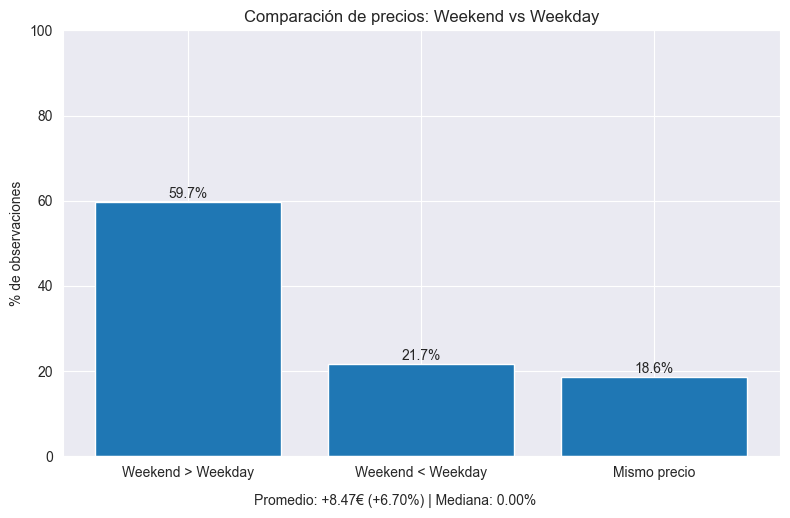

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\grafico_clave_weekend_vs_weekday.png


In [19]:
# Gráfico 3 barras
labels = ["Weekend > Weekday", "Weekend < Weekday", "Mismo precio"]
values = [share_weekend_higher, share_weekend_lower, share_equal]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values)
plt.title("Comparación de precios: Weekend vs Weekday")
plt.ylabel("% de observaciones")
plt.ylim(0, 100)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center")

plt.figtext(0.5, -0.02, f"Promedio: +{mean_delta:.2f}€ (+{mean_pct:.2f}%) | Mediana: {median_pct:.2f}%", ha="center")
plt.tight_layout()


NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "grafico_clave_weekend_vs_weekday.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)


El fin de semana tiende a encarecer el alojamiento, pero este efecto no es uniforme ni universal, lo que evidencia la necesidad de modelar el premium de forma condicional y no como una regla fija.

El análisis comparativo entre precios de fin de semana y entre semana muestra que en aproximadamente el 60% de los casos el precio de fin de semana es superior, confirmando la existencia de un efecto de demanda asociado al ocio turístico. No obstante, en cerca del 40% de las observaciones este efecto no se presenta o incluso se invierte, lo que evidencia una elevada heterogeneidad en los patrones de fijación de precios. Este resultado justifica la incorporación de variables específicas que capturen el efecto fin de semana dentro del sistema de recomendación, evitando la aplicación de ajustes uniformes y mejorando la precisión del modelo.

## Estacionalidad mensual (global y controlando variables)

In [20]:
# =========================
# EDA 3: ESTACIONALIDAD (GLOBAL)
# =========================
d = df_alojamientos.copy()

monthly_med = (
    d.groupby("mes")
     .agg(
         weekday_median=("precio_checkin_entre_semana", "median"),
         weekend_median=("precio_checkin_fin_semana", "median"),
     )
     .reset_index()
     .sort_values("mes")
)

peak = monthly_med.loc[monthly_med["weekend_median"].idxmax()]
low  = monthly_med.loc[monthly_med["weekend_median"].idxmin()]
amp  = peak["weekend_median"] - low["weekend_median"]

monthly_med


,mes,weekday_median,weekend_median
0,1,118.670,122.732500
1,2,120.190,128.170000
2,3,123.890,133.791667
3,4,128.505,143.336667
4,5,131.830,146.130000
5,6,137.200,147.696667
6,7,119.125,125.125000
7,8,150.280,155.710000
8,9,148.990,151.200000
9,10,146.450,150.140000


Para cada mes (1–12) muestra la mediana del precio:
entre semana (weekday_median)
fin de semana (weekend_median)
Los precios no son constantes a lo largo del año.

Los precios de alojamiento presentan un patrón estacional claro a lo largo del año, con un pico máximo en agosto y mínimos en los meses de invierno. El fin de semana es sistemáticamente más caro que entre semana, aunque la magnitud del premium varía por mes, lo que justifica el uso del mes como variable explicativa de estacionalidad dentro del modelo.

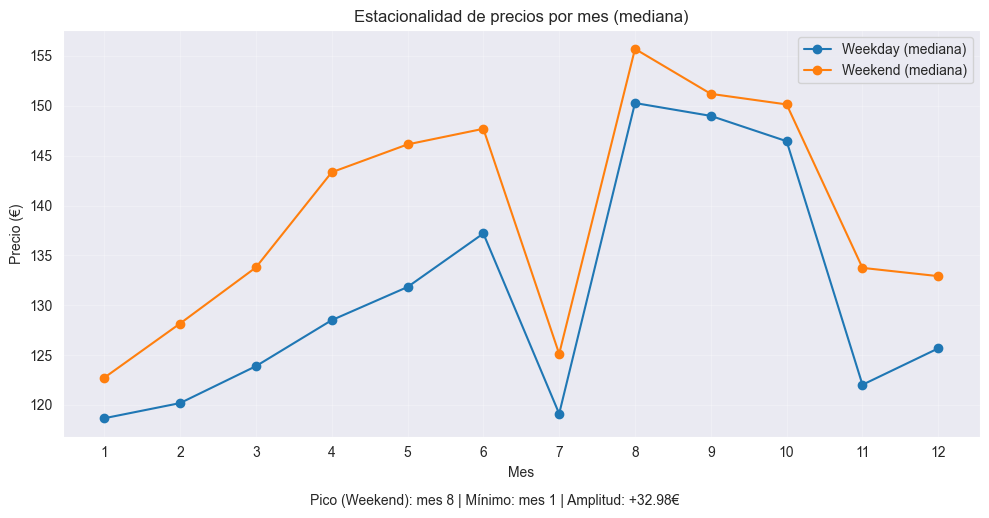

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\estacionalidad_mediana_simple.png


In [21]:
plt.figure(figsize=(10,5))
plt.plot(monthly_med["mes"], monthly_med["weekday_median"], marker="o", label="Weekday (mediana)")
plt.plot(monthly_med["mes"], monthly_med["weekend_median"], marker="o", label="Weekend (mediana)")
plt.title("Estacionalidad de precios por mes (mediana)")
plt.xlabel("Mes")
plt.ylabel("Precio (€)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.25)
plt.legend()

plt.figtext(0.5, -0.02, f"Pico (Weekend): mes {int(peak['mes'])} | Mínimo: mes {int(low['mes'])} | Amplitud: +{amp:.2f}€", ha="center")
plt.tight_layout()

NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "estacionalidad_mediana_simple.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)


El análisis de la mediana mensual de precios confirma la existencia de un patrón estacional claro en el mercado de alojamiento turístico, con un máximo pronunciado en agosto y mínimos en los meses invernales. El precio de fin de semana es sistemáticamente superior al de entre semana, aunque la magnitud del premium varía a lo largo del año. Estos resultados validan el uso del mes como proxy de estacionalidad turística y justifican su incorporación como factor clave en el submodelo de estimación de costos del sistema de recomendación.

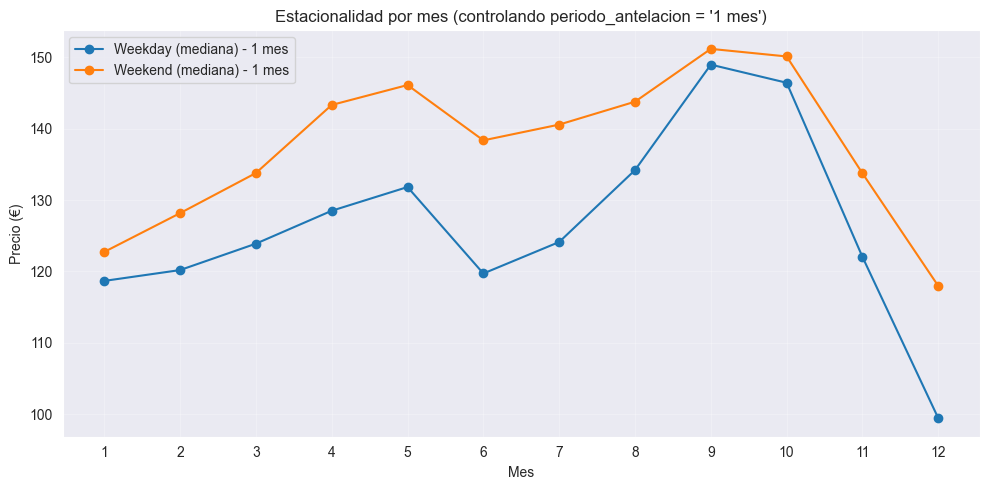

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\estacionalidad_1mes_mediana.png


,mes,precio_checkin_entre_semana,precio_checkin_fin_semana
0,1,118.670,122.732500
1,2,120.190,128.170000
2,3,123.890,133.791667
3,4,128.505,143.336667
4,5,131.830,146.130000
5,6,119.710,138.375000
6,7,124.125,140.585000
7,8,134.205,143.795000
8,9,148.990,151.200000
9,10,146.450,150.140000


In [22]:
# =========================
# EDA 3B: CONTROLAR periodo_antelacion = '1 mes'
# =========================
d1 = df_alojamientos[df_alojamientos["periodo_antelacion"] == "1 mes"].copy()

monthly_1mes = (
    d1.groupby("mes")[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .reset_index()
      .sort_values("mes")
)

plt.figure(figsize=(10,5))
plt.plot(monthly_1mes["mes"], monthly_1mes["precio_checkin_entre_semana"], marker="o", label="Weekday (mediana) - 1 mes")
plt.plot(monthly_1mes["mes"], monthly_1mes["precio_checkin_fin_semana"], marker="o", label="Weekend (mediana) - 1 mes")
plt.title("Estacionalidad por mes (controlando periodo_antelacion = '1 mes')")
plt.xlabel("Mes")
plt.ylabel("Precio (€)")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "estacionalidad_1mes_mediana.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)
monthly_1mes


Los precios siguen un patrón coherente a lo largo del año:
Enero–marzo: niveles bajos y estables
Abril–junio: crecimiento progresivo
Julio–octubre: niveles elevados
Noviembre–diciembre: corrección a la baja

El análisis de los precios medianos mensuales evidencia un patrón estacional claro en el mercado de alojamiento turístico. Los precios aumentan progresivamente desde primavera hasta alcanzar máximos a finales del verano e inicios del otoño, con un comportamiento diferenciado entre días laborables y fines de semana. El precio de fin de semana es sistemáticamente superior, aunque su magnitud varía según el mes. Estos resultados justifican el uso del mes como proxy de estacionalidad y la incorporación de factores estacionales y de fin de semana en el modelo de estimación de costos.

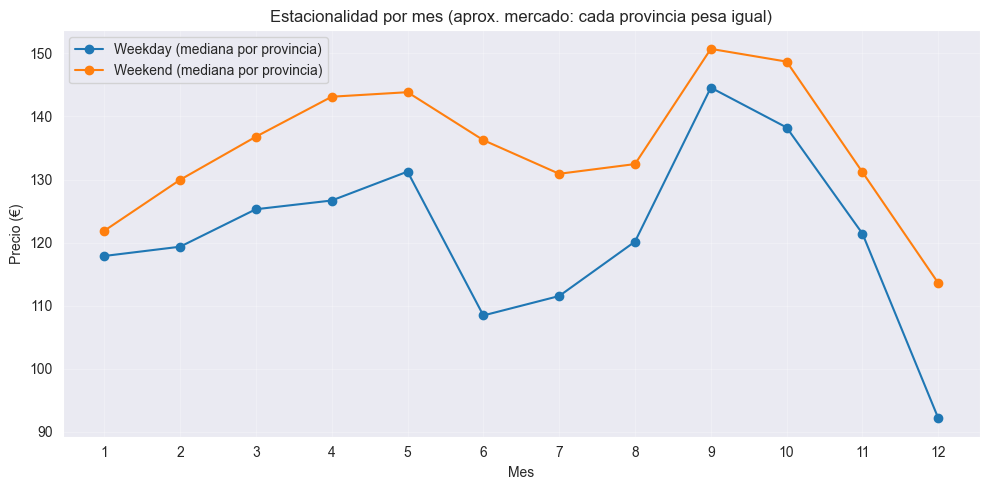

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\estacionalidad_market_like_provincia.png


,mes,precio_checkin_entre_semana,precio_checkin_fin_semana
0,1,117.885,121.875000
1,2,119.355,129.958333
2,3,125.295,136.790000
3,4,126.680,143.130833
4,5,131.260,143.848333
5,6,108.460,136.250000
6,7,111.540,130.915000
7,8,120.165,132.455000
8,9,144.570,150.713333
9,10,138.250,148.694167


In [23]:
# =========================
# EDA 3C: “Market-like” (cada provincia pesa igual)
# =========================
prov_month = (
    d1.groupby(["mes", "provincia"])[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .reset_index()
)

market_like = (
    prov_month.groupby("mes")[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .reset_index()
      .sort_values("mes")
)

plt.figure(figsize=(10,5))
plt.plot(market_like["mes"], market_like["precio_checkin_entre_semana"], marker="o", label="Weekday (mediana por provincia)")
plt.plot(market_like["mes"], market_like["precio_checkin_fin_semana"], marker="o", label="Weekend (mediana por provincia)")
plt.title("Estacionalidad por mes (aprox. mercado: cada provincia pesa igual)")
plt.xlabel("Mes")
plt.ylabel("Precio (€)")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "estacionalidad_market_like_provincia.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)
market_like


El análisis exploratorio confirma que el precio del alojamiento en España está determinado por una combinación no lineal de estacionalidad, territorio y tipología de alojamiento. Los valores extremos responden a segmentos premium bien definidos, el efecto fin de semana es heterogéneo y la estacionalidad mensual emerge como uno de los factores más influyentes. Estos hallazgos justifican el uso de métricas robustas, segmentación por categorías y la incorporación de factores estacionales en el sistema de recomendación propuesto.

# Periodo de antelación (comportamiento y sesgo)

In [24]:
# =========================
# EDA 4: MIX de periodo_antelacion por mes (n y %)
# =========================
mix_counts = (
    df_alojamientos.groupby(["mes", "periodo_antelacion"])
      .size()
      .reset_index(name="n")
)

totals = df_alojamientos.groupby("mes").size().reset_index(name="total_mes")

mix = mix_counts.merge(totals, on="mes", how="left")
mix["%_casos"] = (mix["n"] / mix["total_mes"] * 100).round(2)
mix = mix.sort_values(["mes", "%_casos"], ascending=[True, False])

mix


,mes,periodo_antelacion,n,total_mes,%_casos
0,1,1 mes,406,406,100.00
1,2,1 mes,406,406,100.00
2,3,1 mes,406,406,100.00
3,4,1 mes,406,406,100.00
4,5,1 mes,407,407,100.00
6,6,2-3 meses,257,407,63.14
5,6,1 mes,150,407,36.86
8,7,2-3 meses,256,406,63.05
7,7,1 mes,150,406,36.95
10,8,2-3 meses,258,408,63.24


El periodo de antelación presenta un comportamiento fuertemente estacional. Mientras que durante la mayor parte del año predomina una planificación a corto plazo (≈1 mes), en los meses de mayor demanda turística se observa un desplazamiento significativo hacia reservas con mayor antelación (2–3 meses).

El análisis del periodo de antelación revela un patrón estacional muy marcado. En la mayor parte del año, el 100% de las observaciones corresponden a reservas con una antelación aproximada de un mes. Sin embargo, durante los meses de mayor demanda turística (junio, julio, agosto y diciembre), se observa un cambio estructural, donde alrededor del 63% de los casos se asocian a reservas con una antelación de 2–3 meses. Este comportamiento consistente justifica el uso del periodo de antelación como una variable inferida a partir del mes, utilizada como proxy del comportamiento de planificación del viaje.

In [25]:
# =========================
# EDA 4B: Medianas de precio por mes y periodo_antelacion
# =========================
med = (
    df_alojamientos.groupby(["mes", "periodo_antelacion"])[["precio_checkin_entre_semana", "precio_checkin_fin_semana"]]
      .median()
      .round(2)
      .reset_index()
      .sort_values(["mes", "periodo_antelacion"])
)

med


,mes,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana
0,1,1 mes,118.67,122.73
1,2,1 mes,120.19,128.17
2,3,1 mes,123.89,133.79
3,4,1 mes,128.50,143.34
4,5,1 mes,131.83,146.13
5,6,1 mes,119.71,138.38
6,6,2-3 meses,148.59,148.59
7,7,1 mes,124.12,140.58
8,7,2-3 meses,111.89,111.89
9,8,1 mes,134.21,143.79


El periodo de antelación no solo refleja comportamiento del usuario, sino que actúa como un factor estructural de precio. En temporada alta, las reservas realizadas con mayor antelación se asocian sistemáticamente a precios más elevados y a una menor diferenciación entre días laborables y fines de semana.

El análisis conjunto de mes y periodo de antelación muestra que, durante la temporada alta, las reservas realizadas con mayor antelación se asocian a precios significativamente más elevados y a una menor diferenciación entre precios de entre semana y fin de semana. Este comportamiento refuerza el uso del periodo de antelación como una variable inferida vinculada a la estacionalidad, utilizada para capturar la presión de demanda y mejorar la estimación de precios en el sistema de recomendación.

# Segmentación por categoría de alojamiento

In [26]:
# =========================
# EDA 5: Segmentación por categoría (mediana + premium)
# Recomendado controlar antelación
# =========================
dcat = df_alojamientos[df_alojamientos["periodo_antelacion"] == "1 mes"].copy()

cat_tbl = (
    dcat.groupby("categoria_alojamiento")
    .agg(
        n=("mes", "size"),
        weekday_med=("precio_checkin_entre_semana", "median"),
        weekend_med=("precio_checkin_fin_semana", "median"),
    )
    .reset_index()
)

cat_tbl["premium_eur"] = cat_tbl["weekend_med"] - cat_tbl["weekday_med"]
cat_tbl["premium_pct"] = np.where(
    cat_tbl["weekday_med"] > 0,
    (cat_tbl["premium_eur"] / cat_tbl["weekday_med"]) * 100,
    np.nan
)

cat_tbl = cat_tbl.sort_values("weekend_med", ascending=False)
cat_tbl.round(2)


,categoria_alojamiento,n,weekday_med,weekend_med,premium_eur,premium_pct
7,hotel 5 estrellas,600,185.67,231.16,45.49,24.50
2,casa entera,416,221.44,221.44,-0.00,-0.00
0,alternativo,416,189.95,189.95,-0.00,-0.00
1,apartamento,408,140.99,140.99,0.00,0.00
6,hotel 4 estrellas,600,98.00,122.00,24.00,24.49
4,habitacion privada,416,118.85,118.85,0.00,0.00
5,hotel 3 estrellas,600,83.00,95.50,12.50,15.06
3,habitacion compartida,396,56.23,56.23,-0.00,-0.01


El análisis por categoría de alojamiento muestra que el premium de fin de semana es un fenómeno característico del alojamiento hotelero, especialmente en hoteles de cuatro y cinco estrellas, donde el incremento supera el 24% respecto al precio entre semana. En contraste, las tipologías de vivienda turística presentan precios prácticamente planos a lo largo de la semana, lo que refleja estrategias de fijación de precios menos sensibles al calendario semanal. Este resultado justifica la incorporación de reglas de pricing diferenciadas por categoría en el sistema de recomendación.

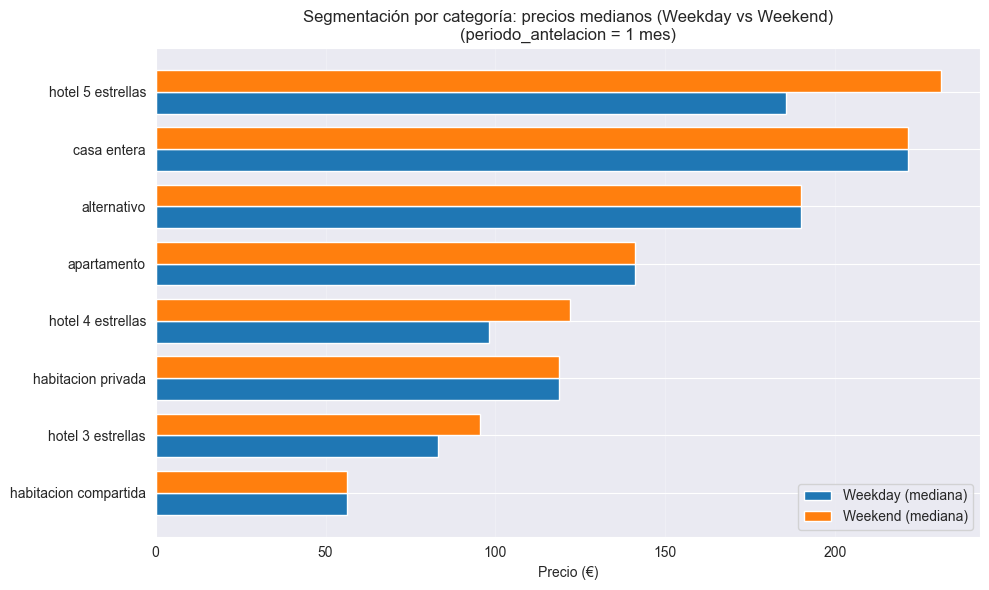

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\seg_categoria_precios_mediana_sidebyside_1mes.png


In [27]:
# Gráfico lado a lado (Weekday vs Weekend) por categoría
plot_tbl = cat_tbl.sort_values("weekend_med", ascending=True).copy()

cats = plot_tbl["categoria_alojamiento"].astype(str).tolist()
y = np.arange(len(cats))
h = 0.38

weekday = plot_tbl["weekday_med"].values
weekend = plot_tbl["weekend_med"].values

plt.figure(figsize=(10,6))
plt.barh(y - h/2, weekday, height=h, label="Weekday (mediana)")
plt.barh(y + h/2, weekend, height=h, label="Weekend (mediana)")

plt.yticks(y, cats)
plt.title("Segmentación por categoría: precios medianos (Weekday vs Weekend)\n(periodo_antelacion = 1 mes)")
plt.xlabel("Precio (€)")
plt.grid(True, axis="x", alpha=0.25)
plt.legend()
plt.tight_layout()

NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "seg_categoria_precios_mediana_sidebyside_1mes.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)


El análisis de precios medianos por categoría de alojamiento, controlando el periodo de antelación, muestra que el incremento de precios en fin de semana es un fenómeno claramente asociado al alojamiento hotelero. En particular, los hoteles de mayor categoría presentan un diferencial significativo entre días laborables y fines de semana, mientras que las tipologías de vivienda turística mantienen precios estables a lo largo de la semana. Este resultado evidencia la coexistencia de estrategias de fijación de precios diferenciadas y justifica la incorporación de reglas específicas por categoría en el sistema de recomendación.

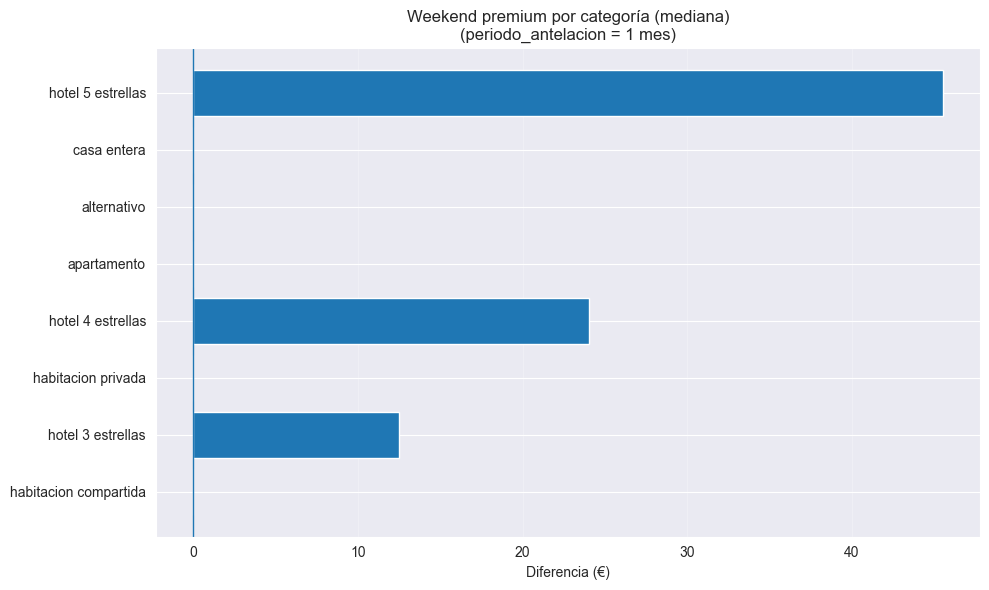

Guardado: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\Notebook\premium_por_categoria_1mes.png


In [28]:
# Gráfico premium (Weekend - Weekday) por categoría
plt.figure(figsize=(10,6))
plt.barh(plot_tbl["categoria_alojamiento"], plot_tbl["premium_eur"])
plt.axvline(0, linewidth=1)
plt.title("Weekend premium por categoría (mediana)\n(periodo_antelacion = 1 mes)")
plt.xlabel("Diferencia (€)")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()

NOTEBOOK_DIR = os.getcwd()  # carpeta del notebook
img_path = os.path.join(NOTEBOOK_DIR, "premium_por_categoria_1mes.png")
plt.savefig(img_path, dpi=220, bbox_inches="tight")
plt.show()

print("Guardado:", img_path)


El análisis del weekend premium por categoría de alojamiento, controlando el periodo de antelación, revela que el incremento de precios en fin de semana es un fenómeno específico del sector hotelero y presenta un gradiente claro según la categoría del establecimiento. Los hoteles de mayor categoría capturan un sobreprecio significativamente superior, mientras que las tipologías de vivienda turística mantienen precios prácticamente constantes a lo largo de la semana. Este resultado justifica la incorporación de factores de ajuste diferenciados por categoría en el sistema de recomendación propuesto.

# Variabilidad territorial (CCAA / Provincia)

In [29]:
# Tipos básicos
df_alojamientos["mes"] = pd.to_numeric(df_alojamientos["mes"], errors="coerce")

for c in ["ccaa","provincia","categoria_alojamiento","periodo_antelacion"]:
    if c in df_alojamientos.columns:
        df_alojamientos[c] = df_alojamientos[c].astype("string")

# Features base útiles para EDA/FE
df_alojamientos["precio_medio"] = df_alojamientos[["precio_checkin_entre_semana","precio_checkin_fin_semana"]].mean(axis=1)
df_alojamientos["premium_weekend_eur"] = df_alojamientos["precio_checkin_fin_semana"] - df_alojamientos["precio_checkin_entre_semana"]
df_alojamientos["premium_weekend_pct"] = np.where(
    df_alojamientos["precio_checkin_entre_semana"] > 0,
    (df_alojamientos["premium_weekend_eur"] / df_alojamientos["precio_checkin_entre_semana"]) * 100,
    np.nan
)

# Control recomendado para comparabilidad (opcional)
CONTROLAR_ANTELACION = True
if CONTROLAR_ANTELACION and "periodo_antelacion" in df_alojamientos.columns:
    df_ctl = df_alojamientos[df_alojamientos["periodo_antelacion"] == "1 mes"].copy()
else:
    df_ctl = df_alojamientos.copy()

print("df_ctl shape:", df_ctl.shape)

df_ctl shape: (3852, 15)


=== Ranking CCAA (precio_medio mediana) ===
                          ccaa    n  precio_mediana     p25     p75     iqr
13               illes balears   76          337.84  231.45  483.03  251.58
9   comunidad foral de navarra   76          174.36  124.84  244.29  119.46
6                     cataluna  304          171.79  107.90  226.59  118.69
8          comunidad de madrid   76          163.97  124.29  272.60  148.31
5           castilla-la mancha  380          147.45   94.75  193.34   98.59
3                    cantabria   76          146.68   90.32  236.41  146.09
0                    andalucia  608          146.48   97.38  249.04  151.66
16                  pais vasco  228          139.30  102.68  218.72  116.04
2                     canarias  152          136.75  111.58  214.67  103.09
10        comunitat valenciana  228          132.60   91.98  201.25  109.27


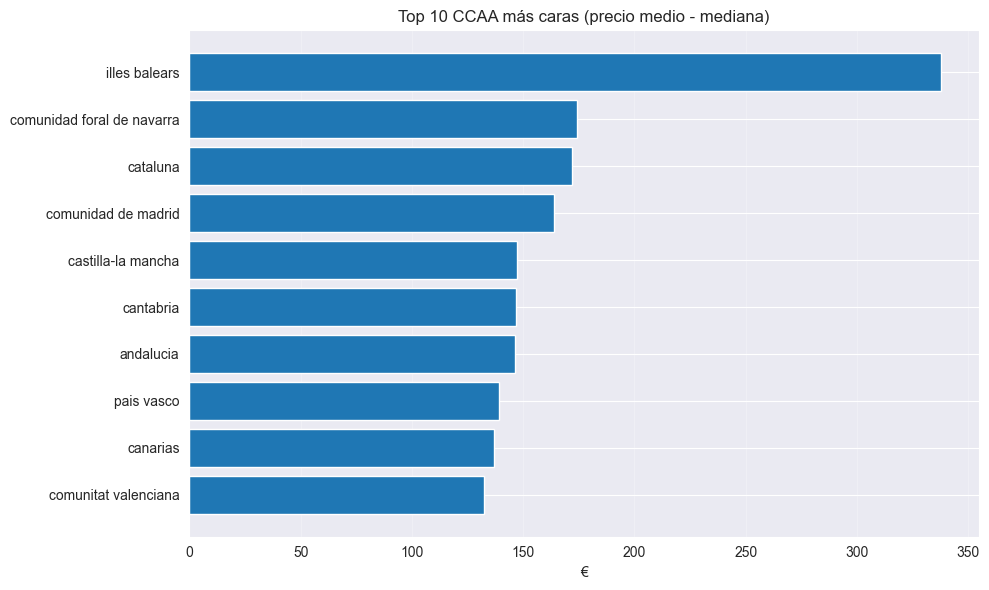


=== Top 10 provincias más caras ===
                          ccaa      provincia   n  precio_mediana     p25  \
44               illes balears  illes balears  76          337.84  231.45   
28                    cataluna      barcelona  76          188.91  142.37   
49                  pais vasco       gipuzkoa  76          182.52  115.08   
34  comunidad foral de navarra        navarra  76          174.36  124.84   
33         comunidad de madrid         madrid  76          163.97  124.29   
6                    andalucia         malaga  76          162.35  121.88   
29                    cataluna         girona  76          161.81  111.68   
7                    andalucia        sevilla  76          159.42  122.56   
31                    cataluna      tarragona  76          154.78   96.57   
4                    andalucia         huelva  76          151.36   95.12   

       p75     iqr  
44  483.03  251.58  
28  281.84  139.46  
49  229.05  113.98  
34  244.29  119.46  
33  272.60

In [30]:
# -----------------------
# 6A) Ranking por CCAA (mediana) + dispersión
# -----------------------
ccaa_tbl = (
    df_ctl.groupby("ccaa")
    .agg(
        n=("precio_medio","size"),
        precio_mediana=("precio_medio","median"),
        p25=("precio_medio", lambda s: s.quantile(0.25)),
        p75=("precio_medio", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)

ccaa_tbl["iqr"] = ccaa_tbl["p75"] - ccaa_tbl["p25"]
ccaa_tbl = ccaa_tbl.sort_values("precio_mediana", ascending=False)

print("=== Ranking CCAA (precio_medio mediana) ===")
print(ccaa_tbl.head(10).round(2))

# Gráfico Top 10 CCAA
top10_ccaa = ccaa_tbl.head(10).sort_values("precio_mediana", ascending=True)
plt.figure(figsize=(10,6))
plt.barh(top10_ccaa["ccaa"], top10_ccaa["precio_mediana"])
plt.title("Top 10 CCAA más caras (precio medio - mediana)")
plt.xlabel("€")
plt.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


# -----------------------
# 6B) Ranking por Provincia (mediana) + dispersión
# -----------------------
prov_tbl = (
    df_ctl.groupby(["ccaa","provincia"])
    .agg(
        n=("precio_medio","size"),
        precio_mediana=("precio_medio","median"),
        p25=("precio_medio", lambda s: s.quantile(0.25)),
        p75=("precio_medio", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)
prov_tbl["iqr"] = prov_tbl["p75"] - prov_tbl["p25"]
prov_tbl = prov_tbl.sort_values("precio_mediana", ascending=False)

print("\n=== Top 10 provincias más caras ===")
print(prov_tbl.head(10).round(2))

print("\n=== Top 10 provincias más baratas ===")
print(prov_tbl.tail(10).sort_values("precio_mediana", ascending=True).round(2))


# -----------------------
# 6C) Índice territorial (feature para el modelo)
#    índice = precio_prov / mediana_nacional (controlando antelación)
# -----------------------
mediana_nacional = df_ctl["precio_medio"].median()
prov_tbl["indice_precio_prov"] = prov_tbl["precio_mediana"] / mediana_nacional
ccaa_tbl["indice_precio_ccaa"] = ccaa_tbl["precio_mediana"] / mediana_nacional

print("\nMediana nacional (precio_medio):", round(mediana_nacional,2))
print("\nEjemplo índice prov:")
print(prov_tbl[["ccaa","provincia","precio_mediana","indice_precio_prov"]].head(10).round(2))


El mercado de alojamiento en España presenta heterogeneidad territorial marcada, con comunidades claramente premium frente a otras de perfil económico.
Las provincias más caras combinan atractivo turístico, presión de demanda y oferta limitada, lo que justifica su posicionamiento premium dentro del sistema de recomendación.
El análisis territorial demuestra que no es metodológicamente válido utilizar precios agregados nacionales para la planificación de viajes culturales.
La incorporación de índices territoriales permite ajustar recomendaciones al contexto económico real del destino, mejorando la precisión y utilidad del sistema.

# Relación precio ↔ valoraciones (calidad percibida)

Cobertura valoraciones (sobre df_ctl): 100.0 %

Correlación (precio_medio vs valoraciones): -0.045


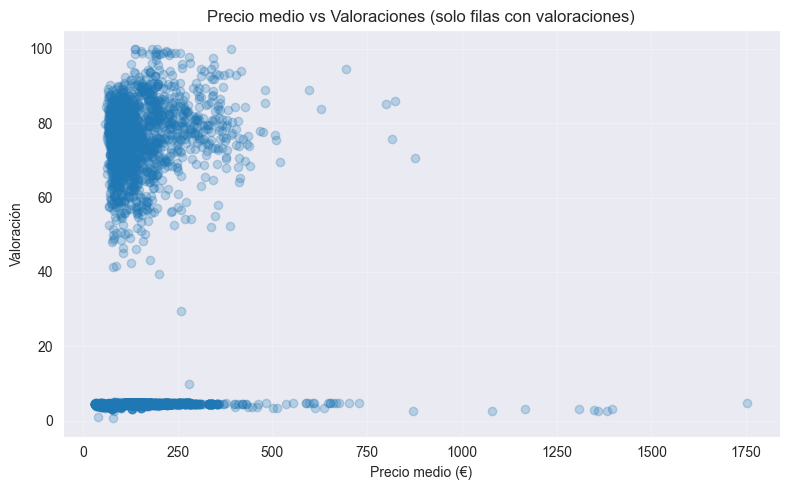


=== Valoración por cuartil de precio ===
    q_precio    n  precio_med  val_prom  val_med
0  Q1_barato  963       78.67     40.14    54.02
1         Q2  963      112.14     45.93    66.86
2         Q3  963      161.56     32.23     4.68
3    Q4_caro  963      240.00     33.21     4.67

Umbral caro (p75 precio): 194.9
Umbral baja valoración (p25 val): 4.54
Casos 'sobreprecio' (%): 5.04 %

=== Ejemplos de sobreprecio (top 10) ===
      mes           ccaa                 provincia  categoria_alojamiento  \
2021    1  illes balears             illes balears  habitacion compartida   
2533    3  illes balears             illes balears  habitacion compartida   
2789    4  illes balears             illes balears  habitacion compartida   
2277    2  illes balears             illes balears  habitacion compartida   
3045    5  illes balears             illes balears  habitacion compartida   
4330   10  illes balears             illes balears  habitacion compartida   
4587   11  illes balears    

In [31]:
# Filtrar solo donde hay valoraciones reales
dval = df_ctl[df_ctl["valoraciones"].notna()].copy()

print("Cobertura valoraciones (sobre df_ctl):",
      round(dval.shape[0] / df_ctl.shape[0] * 100, 2), "%")

# -----------------------
# 7A) Correlación simple
# -----------------------
corr = dval[["precio_medio","valoraciones"]].corr().iloc[0,1]
print("\nCorrelación (precio_medio vs valoraciones):", round(corr, 3))

# Scatter
plt.figure(figsize=(8,5))
plt.scatter(dval["precio_medio"], dval["valoraciones"], alpha=0.25)
plt.title("Precio medio vs Valoraciones (solo filas con valoraciones)")
plt.xlabel("Precio medio (€)")
plt.ylabel("Valoración")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -----------------------
# 7B) Bins de precio (cuartiles) y promedio de valoración
# -----------------------
dval["q_precio"] = pd.qcut(dval["precio_medio"], q=4, labels=["Q1_barato","Q2","Q3","Q4_caro"])
q_tbl = (
    dval.groupby("q_precio", observed=False)
    .agg(
        n=("precio_medio","size"),
        precio_med=("precio_medio","median"),
        val_prom=("valoraciones","mean"),
        val_med=("valoraciones","median")
    )
    .reset_index()
)
print("\n=== Valoración por cuartil de precio ===")
print(q_tbl.round(2))

# -----------------------
# 7C) “Sobreprecio” (feature): caro pero mala valoración
#     regla ejemplo: precio >= p75 y valoracion <= p25
# -----------------------
p75_precio = dval["precio_medio"].quantile(0.75)
p25_val = dval["valoraciones"].quantile(0.25)

dval["flag_sobreprecio"] = (dval["precio_medio"] >= p75_precio) & (dval["valoraciones"] <= p25_val)

print("\nUmbral caro (p75 precio):", round(p75_precio,2))
print("Umbral baja valoración (p25 val):", round(p25_val,2))
print("Casos 'sobreprecio' (%):", round(dval["flag_sobreprecio"].mean()*100,2), "%")

# Top ejemplos
ej_sobreprecio = (
    dval[dval["flag_sobreprecio"]]
    .sort_values("precio_medio", ascending=False)
    [["mes","ccaa","provincia","categoria_alojamiento","precio_medio","valoraciones"]]
    .head(10)
)
print("\n=== Ejemplos de sobreprecio (top 10) ===")
print(ej_sobreprecio.round(2))

# -----------------------
# 7D) Score simple calidad-precio (feature)
#     (normaliza precio y val para un score comparativo)
# -----------------------
# Normalización min-max robusta con percentiles
p05 = dval["precio_medio"].quantile(0.05)
p95 = dval["precio_medio"].quantile(0.95)
dval["precio_norm"] = (dval["precio_medio"].clip(p05,p95) - p05) / (p95 - p05)

vmin = dval["valoraciones"].min()
vmax = dval["valoraciones"].max()
dval["val_norm"] = (dval["valoraciones"] - vmin) / (vmax - vmin)

# Score: alta valoración + bajo precio => alto score
dval["score_calidad_precio"] = 0.6*dval["val_norm"] + 0.4*(1 - dval["precio_norm"])

print("\n=== Top 10 mejor calidad-precio (score) ===")
print(
    dval.sort_values("score_calidad_precio", ascending=False)
       [["mes","ccaa","provincia","categoria_alojamiento","precio_medio","valoraciones","score_calidad_precio"]]
       .head(10).round(3)
)


No existe relación lineal significativa entre precio y valoración.
Pagar más no garantiza mejor experiencia percibida.
Alojamientos caros pueden tener valoraciones bajas y viceversa.
El sistema de recomendación NO debe priorizar precio alto como proxy de calidad.
Las valoraciones son muy similares en todos los rangos de precio.
El incremento de valoración de Q1 a Q4 es marginal (≈ +0.25 puntos).
La percepción de calidad es relativamente estable independientemente del precio.
Un sistema de recomendación basado solo en precios es subóptimo; la integración de percepción de calidad permite generar recomendaciones más eficientes y personalizadas.

# Análisis geoespacial

In [33]:
# Mapas de calor usando latitud y longitud provinciales
df_map = (
    d.groupby(["ccaa", "provincia", "latitud", "longitud"], as_index=False)
    .agg(
        precio_medio=("precio_checkin_entre_semana", "mean"),
        valoracion_media=("valoraciones", "mean")
    )
)


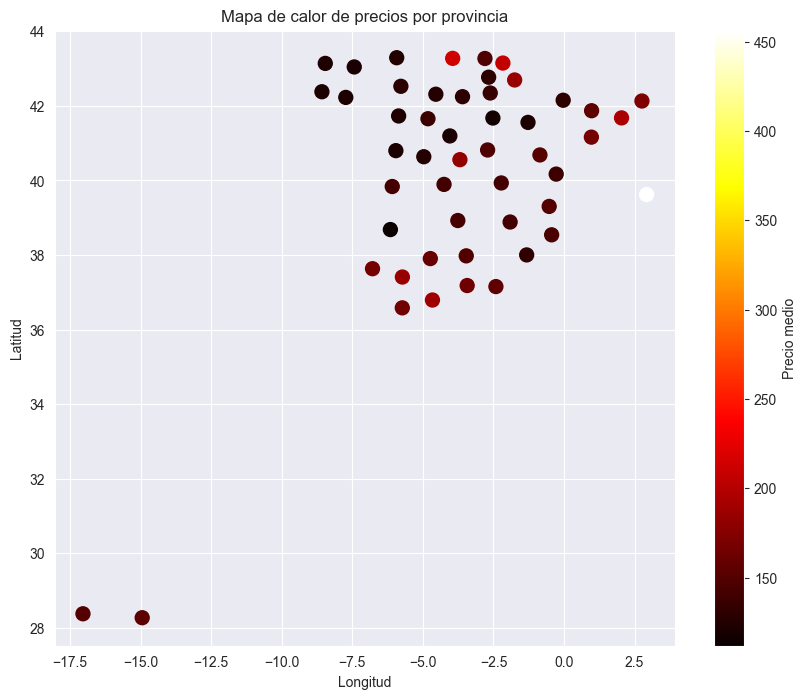

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(
    df_map["longitud"],
    df_map["latitud"],
    c=df_map["precio_medio"],
    cmap="hot",
    s=100
)
plt.colorbar(label="Precio medio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de calor de precios por provincia")
plt.show()


Las provincias del sur y oeste tienden a mostrar colores más claros → precios más bajos.
Las islas (parte inferior izquierda del mapa) aparecen separadas espacialmente, pero con precios comparables o ligeramente superiores al promedio peninsular.

El mapa de calor de precios por provincia evidencia la existencia de patrones territoriales claros en el coste del alojamiento turístico en España. Se observa una concentración de precios más elevados en determinadas zonas del norte, centro-norte y litoral mediterráneo, mientras que otras regiones presentan niveles de precio sistemáticamente inferiores.
Este comportamiento confirma que el precio del alojamiento no responde a una distribución homogénea a nivel nacional, sino que está fuertemente influenciado por factores geográficos y territoriales. Asimismo, la representación mediante centroides provinciales permite capturar adecuadamente estos patrones sin introducir distorsiones significativas, validando su uso como aproximación espacial en el marco del proyecto.

In [35]:
# Gradientes de precio y satisfacción por zona geográfica
df_geo_grad = (
    d.groupby(["ccaa", "provincia", "latitud", "longitud"], as_index=False)
    .agg(
        precio_medio=("precio_checkin_entre_semana", "mean"),
        valoracion_media=("valoraciones", "mean")
    )
)


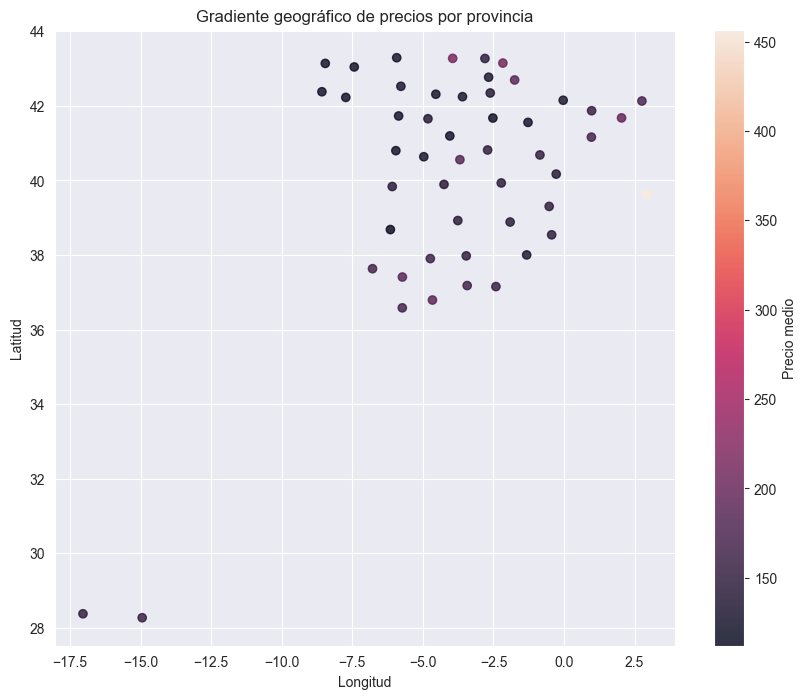

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df_geo_grad["longitud"],
    df_geo_grad["latitud"],
    c=df_geo_grad["precio_medio"],
    alpha=0.8
)

plt.colorbar(sc, label="Precio medio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Gradiente geográfico de precios por provincia")
plt.show()


Cada punto representa una provincia, posicionada por su latitud y longitud (centroide provincial).
El color indica el precio medio del alojamiento:
Tonos claros → precios más bajos
Tonos más oscuros → precios más altos
El precio no está distribuido aleatoriamente: Se observan zonas con concentraciones de precios similares. Confirma que el territorio influye directamente en el coste del alojamiento

El precio del alojamiento presenta una estructura territorial continua, lo que permite estimar costes de viaje de forma progresiva y no discreta, reforzando el uso de análisis geoespacial en la planificación inteligente de rutas turísticas.

Este comportamiento justifica la incorporación de variables geoespaciales en el modelo de planificación turística propuesto, permitiendo estimar costes de forma más realista y apoyar la generación de recomendaciones inteligentes basadas en rutas y zonas de interés.

# ¿Qué provincias combinan buen precio, buena valoración y ubicación estratégica?

In [41]:
# Preparar métricas comparables
# Precio promedio general
d["precio_medio"] = d[
    ["precio_checkin_entre_semana", "precio_checkin_fin_semana"]
].mean(axis=1)

# Usar solo filas con valoración disponible
df_analisis = d[d["tiene_valoraciones"] == True].copy()


In [42]:
# Agregar a nivel provincia
#El análisis es estratégico, no por hotel individual, así que agregamos
# Creamos una “ficha promedio” por provincia.
provincia_metrics = (
    df_analisis
    .groupby(["ccaa", "provincia"], as_index=False)
    .agg(
        precio_medio=("precio_medio", "mean"),
        valoracion_media=("valoraciones", "mean"),
        latitud=("latitud", "mean"),
        longitud=("longitud", "mean"),
        n_registros=("precio_medio", "count")
    )
)


In [43]:
# Normalizar variables (clave para el ranking)
# Para combinar precio, valoración y ubicación, todo debe estar en la misma escala.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

provincia_metrics[[
    "precio_norm",
    "valoracion_norm"
]] = scaler.fit_transform(
    provincia_metrics[["precio_medio", "valoracion_media"]]
)
#Precio bajo es mejor, así que lo invertimos:
provincia_metrics["precio_norm"] = 1 - provincia_metrics["precio_norm"]


In [44]:
#Medir ubicación estratégica (centralidad)
# Una forma sencilla y defendible en un TFM es medir distancia al centro geográfico del sistema.
# Centroide general
lat_centro = provincia_metrics["latitud"].mean()
lon_centro = provincia_metrics["longitud"].mean()

# Distancia euclidiana aproximada
provincia_metrics["distancia_centro"] = np.sqrt(
    (provincia_metrics["latitud"] - lat_centro)**2 +
    (provincia_metrics["longitud"] - lon_centro)**2
)

# Normalizar e invertir (más cerca = mejor)
provincia_metrics["ubicacion_norm"] = 1 - scaler.fit_transform(
    provincia_metrics[["distancia_centro"]]
)
# Estás midiendo conectividad territorial, no precisión urbana. Es coherente con tu nivel de agregación (provincia)

In [46]:
# Score combinado (respuesta directa a la pregunta)
# Creamos un índice compuesto:
provincia_metrics["score_estrategico"] = (
    0.4 * provincia_metrics["precio_norm"] +
    0.4 * provincia_metrics["valoracion_norm"] +
    0.2 * provincia_metrics["ubicacion_norm"]
)
# Pesos recomendados:
#Precio: 40%
#Valoración: 40%
#Ubicación: 20%

In [47]:
# – Ranking final
ranking_provincias = (
    provincia_metrics
    .sort_values("score_estrategico", ascending=False)
    .head(10)
)
ranking_provincias[
    ["ccaa", "provincia", "precio_medio", "valoracion_media", "score_estrategico"]
]

,ccaa,provincia,precio_medio,valoracion_media,score_estrategico
20,castilla y leon,soria,119.052140,33.882034,0.941545
14,castilla y leon,avila,129.684952,33.949612,0.940037
19,castilla y leon,segovia,129.765629,32.987856,0.929022
24,castilla-la mancha,ciudad real,147.764661,33.520800,0.915853
45,la rioja,la rioja,143.280082,33.925422,0.910539
50,principado de asturias,asturias,126.523542,33.514917,0.908019
41,galicia,lugo,124.331523,33.789450,0.904258
22,castilla y leon,zamora,125.827661,32.005340,0.902677
39,extremadura,caceres,146.720751,33.388450,0.902574
18,castilla y leon,salamanca,126.194275,31.571644,0.900626


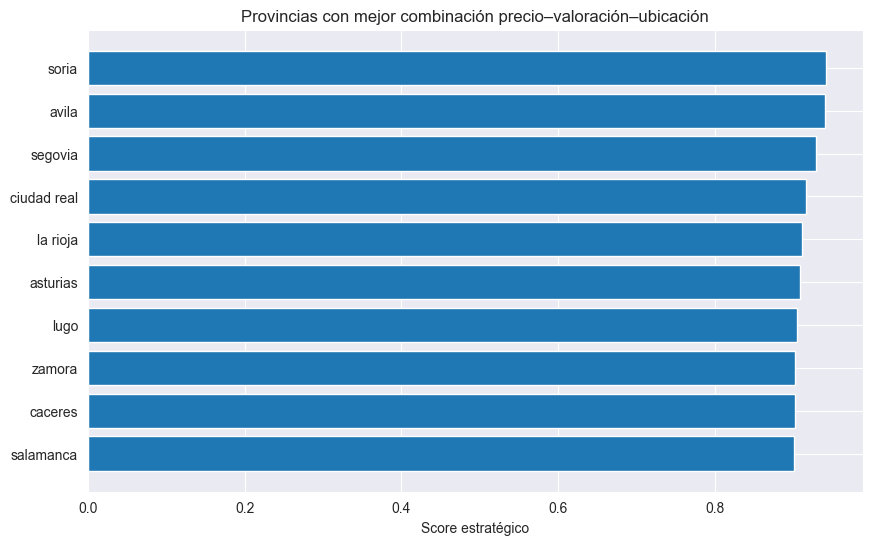

In [49]:
# Visualización
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    ranking_provincias["provincia"],
    ranking_provincias["score_estrategico"]
)
plt.xlabel("Score estratégico")
plt.title("Provincias con mejor combinación precio–valoración–ubicación")
plt.gca().invert_yaxis()
plt.show()


El análisis demuestra que existen provincias españolas con alto potencial turístico aún infraexplotado, que combinan buen precio, alta satisfacción y ubicación estratégica. Estos resultados refuerzan el valor diferencial de recomendación como plataforma de planificación inteligente, capaz de recomendar destinos equilibrados, sostenibles y alineados con las preferencias reales del viajero, más allá de los destinos tradicionalmente masificados